# Рубежный контроль №1
## Нигматуллин Алик Радикович ИУ5-23М

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Загружаем набор данных mpg
df = sns.load_dataset('mpg')
print("Первые 5 строк данных:")
print(df.head())

Первые 5 строк данных:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


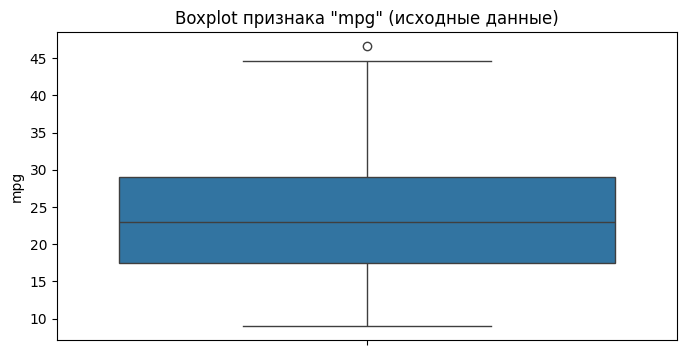

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(y=df['mpg'])
plt.title('Boxplot признака "mpg" (исходные данные)')
plt.ylabel('mpg')
plt.show()

In [ ]:
print("Пропуски в 'horsepower' до обработки:", df['horsepower'].isna().sum())

median_hp = df['horsepower'].median()
print(f"Медиана признака 'horsepower': {median_hp}")

df['horsepower_filled'] = df['horsepower'].fillna(median_hp)

print("Пропуски после заполнения:", df['horsepower_filled'].isna().sum())
print("\nПример заполнения (первые 10 строк столбцов horsepower и horsepower_filled):")
print(df[['horsepower', 'horsepower_filled']].head(10))

Пропуски в 'horsepower' до обработки: 6
Медиана признака 'horsepower': 93.5
Пропуски после заполнения: 0

Пример заполнения (первые 10 строк столбцов horsepower и horsepower_filled):
   horsepower  horsepower_filled
0       130.0              130.0
1       165.0              165.0
2       150.0              150.0
3       150.0              150.0
4       140.0              140.0
5       198.0              198.0
6       220.0              220.0
7       215.0              215.0
8       225.0              225.0
9       190.0              190.0


In [ ]:
low_q = df['mpg'].quantile(0.05)
high_q = df['mpg'].quantile(0.95)
print(f"5% квантиль: {low_q:.2f}")
print(f"95% квантиль: {high_q:.2f}")

outliers_before = ((df['mpg'] < low_q) | (df['mpg'] > high_q)).sum()
print(f"Количество выбросов до обработки: {outliers_before}")

df['mpg_capped'] = df['mpg'].clip(lower=low_q, upper=high_q)

outliers_after = ((df['mpg_capped'] < low_q) | (df['mpg_capped'] > high_q)).sum()
print(f"Количество выбросов после обработки: {outliers_after}")

print("\nСравнение исходного и обработанного 'mpg' (первые 10 строк):")
print(df[['mpg', 'mpg_capped']].head(10))

5% квантиль: 13.00
95% квантиль: 37.03
Количество выбросов до обработки: 33
Количество выбросов после обработки: 0

Сравнение исходного и обработанного 'mpg' (первые 10 строк):
    mpg  mpg_capped
0  18.0        18.0
1  15.0        15.0
2  18.0        18.0
3  16.0        16.0
4  17.0        17.0
5  15.0        15.0
6  14.0        14.0
7  14.0        14.0
8  14.0        14.0
9  15.0        15.0


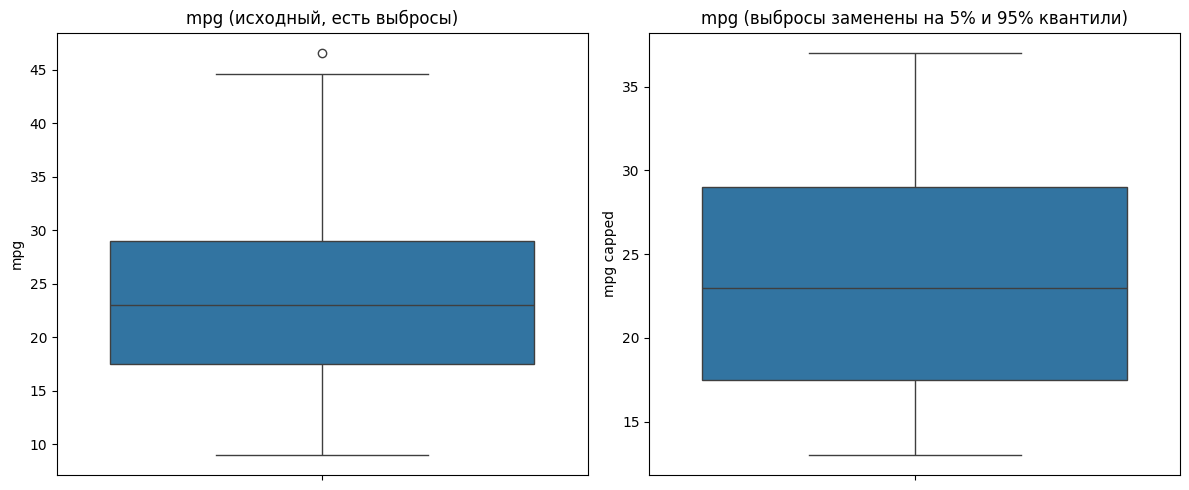

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['mpg'], ax=axes[0])
axes[0].set_title('mpg (исходный, есть выбросы)')
axes[0].set_ylabel('mpg')
sns.boxplot(y=df['mpg_capped'], ax=axes[1])
axes[1].set_title('mpg (выбросы заменены на 5% и 95% квантили)')
axes[1].set_ylabel('mpg capped')
plt.tight_layout()
plt.show()